In [11]:
import pandas as pd 
df = pd.read_csv("C:\econometrie2\projet S2\immobillier\ValeursFoncieres-2024.txt\ValeursFoncieres-2024.txt",
sep="|",
encoding="utf-8",
low_memory=False)
print(df.shape)
print(df.columns.tolist())


(3499931, 43)
['Identifiant de document', 'Reference document', '1 Articles CGI', '2 Articles CGI', '3 Articles CGI', '4 Articles CGI', '5 Articles CGI', 'No disposition', 'Date mutation', 'Nature mutation', 'Valeur fonciere', 'No voie', 'B/T/Q', 'Type de voie', 'Code voie', 'Voie', 'Code postal', 'Commune', 'Code departement', 'Code commune', 'Prefixe de section', 'Section', 'No plan', 'No Volume', '1er lot', 'Surface Carrez du 1er lot', '2eme lot', 'Surface Carrez du 2eme lot', '3eme lot', 'Surface Carrez du 3eme lot', '4eme lot', 'Surface Carrez du 4eme lot', '5eme lot', 'Surface Carrez du 5eme lot', 'Nombre de lots', 'Code type local', 'Type local', 'Identifiant local', 'Surface reelle bati', 'Nombre pieces principales', 'Nature culture', 'Nature culture speciale', 'Surface terrain']


In [12]:
print(df.columns.tolist())

['Identifiant de document', 'Reference document', '1 Articles CGI', '2 Articles CGI', '3 Articles CGI', '4 Articles CGI', '5 Articles CGI', 'No disposition', 'Date mutation', 'Nature mutation', 'Valeur fonciere', 'No voie', 'B/T/Q', 'Type de voie', 'Code voie', 'Voie', 'Code postal', 'Commune', 'Code departement', 'Code commune', 'Prefixe de section', 'Section', 'No plan', 'No Volume', '1er lot', 'Surface Carrez du 1er lot', '2eme lot', 'Surface Carrez du 2eme lot', '3eme lot', 'Surface Carrez du 3eme lot', '4eme lot', 'Surface Carrez du 4eme lot', '5eme lot', 'Surface Carrez du 5eme lot', 'Nombre de lots', 'Code type local', 'Type local', 'Identifiant local', 'Surface reelle bati', 'Nombre pieces principales', 'Nature culture', 'Nature culture speciale', 'Surface terrain']


In [30]:
df75 = df[df["Code departement"] == "75"]
print(df75.shape)
print(df75["Type local"].value_counts())

(74800, 43)
Type local
Dépendance                                  36082
Appartement                                 33180
Local industriel. commercial ou assimilé     4810
Maison                                        137
Name: count, dtype: int64


In [14]:
df75= df75[df75["Type local"].isin(["Appartement","Maison"])]
df75= df75.copy()
df75["Valeur fonciere"] = df75["Valeur fonciere"].astype(str).str.replace(",",".").str.replace(" "," ")
df75["Valeur fonciere"] = pd.to_numeric(df75["Valeur fonciere"], errors="coerce")
df75["Surface reelle bati"] = pd.to_numeric(df75["Surface reelle bati"], errors="coerce")
df75["Prix au m2"] = df75["Valeur fonciere"] / df75["Surface reelle bati"]
df75 = df75.dropna(subset=["Valeur fonciere", "Surface reelle bati", "Prix au m2"])
df75 = df75[df75["Prix au m2"] > 500]   
df75 = df75[df75["Prix au m2"] < 50000] 
print(df75.shape)


(28515, 44)


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns 
df75["Date mutation"] = pd.to_datetime(df75["Date mutation"],dayfirst=True)
df75["Mois"] = df75["Date mutation"].dt.month
print(df75["Mois"].value_counts().sort_index())
print("\nPrix moyen au m2 Paris :", round(df75["Prix au m2"].mean(), 0), "€")


Mois
1     2093
2     2090
3     2305
4     2505
5     2358
6     2765
7     3205
8     1178
9     3020
10    2471
11    1803
12    2722
Name: count, dtype: int64

Prix moyen au m2 Paris : 10913.0 €


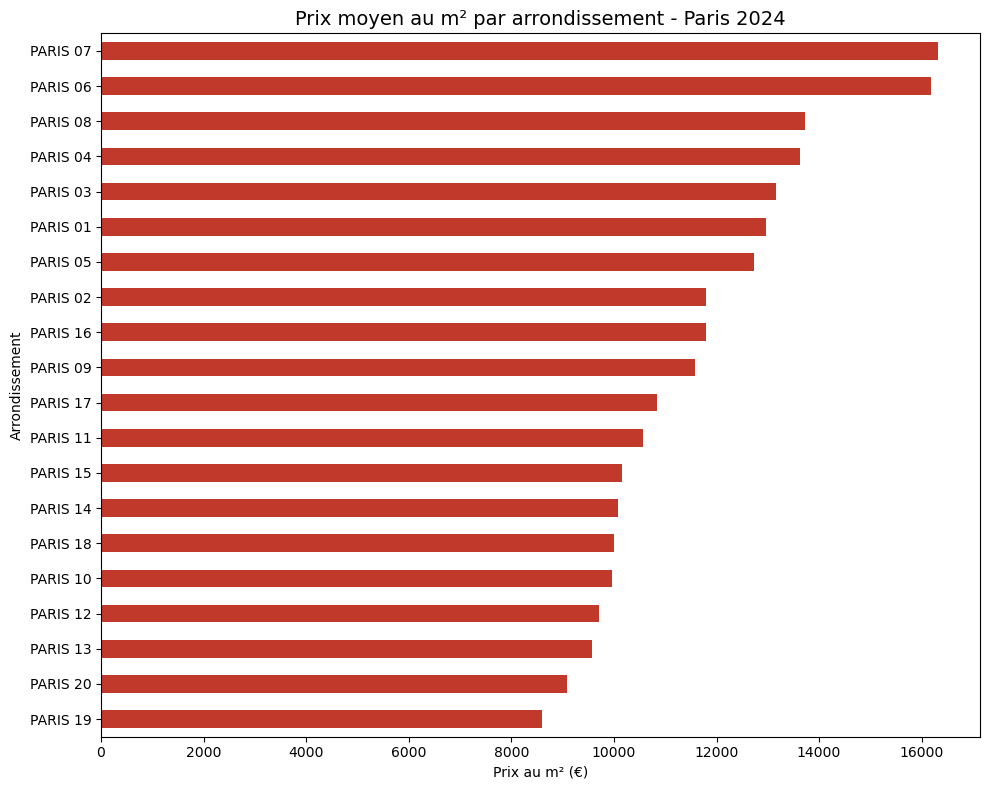

In [ ]:

prix_par_commune = df75.groupby("Commune")["Prix au m2"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 8))
prix_par_commune.plot(kind="barh", ax=ax, color="#c0392b")
ax.set_title("Prix moyen au m² par arrondissement - Paris 2024", fontsize=14)
ax.set_xlabel("Prix au m² (€)")
ax.set_ylabel("Arrondissement")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("prix_par_arrondissement.png", dpi=150)
plt.show()

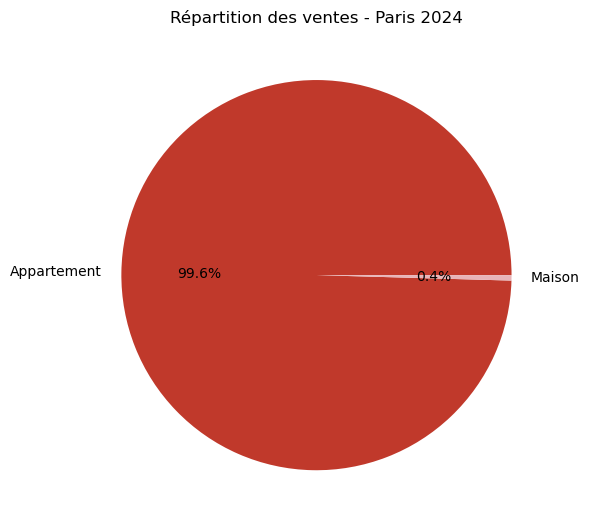

In [20]:
repartition = df75["Type local"].value_counts()
fig, ax = plt.subplots(figsize=(6, 6))
repartition.plot(kind="pie", ax=ax, autopct="%1.1f%%", colors=["#c0392b", "#e8b4b8"])
ax.set_title("Répartition des ventes - Paris 2024")
ax.set_ylabel("")  
plt.tight_layout()
plt.savefig("repartition_types.png", dpi=150)
plt.show()

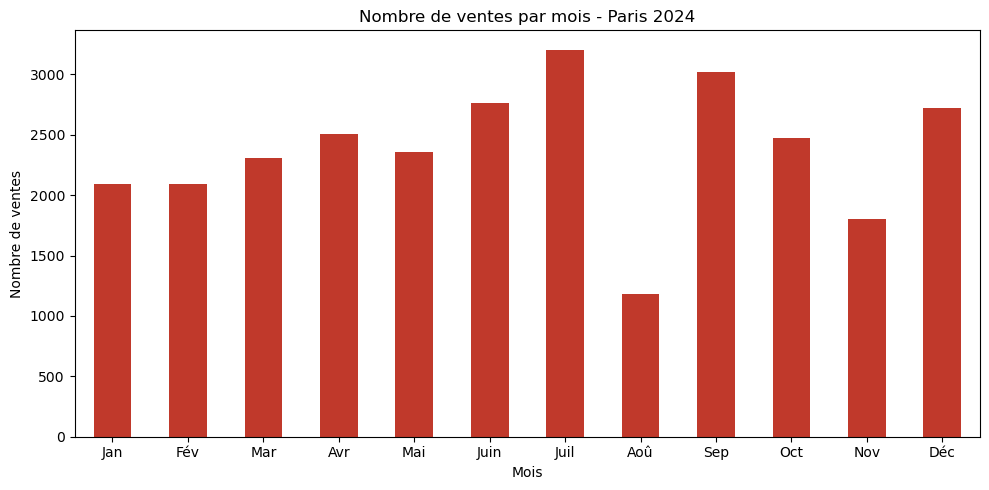

In [22]:
ventes_par_mois = df75.groupby("Mois")["Valeur fonciere"].count()
mois_noms = {1:"Jan", 2:"Fév", 3:"Mar", 4:"Avr", 5:"Mai", 6:"Juin",
             7:"Juil", 8:"Aoû", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Déc"}
ventes_par_mois.index = ventes_par_mois.index.map(mois_noms)
fig, ax = plt.subplots(figsize=(10, 5))
ventes_par_mois.plot(kind="bar", ax=ax, color="#c0392b")
ax.set_title("Nombre de ventes par mois - Paris 2024")
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de ventes")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("ventes_par_mois.png", dpi=150)
plt.show()

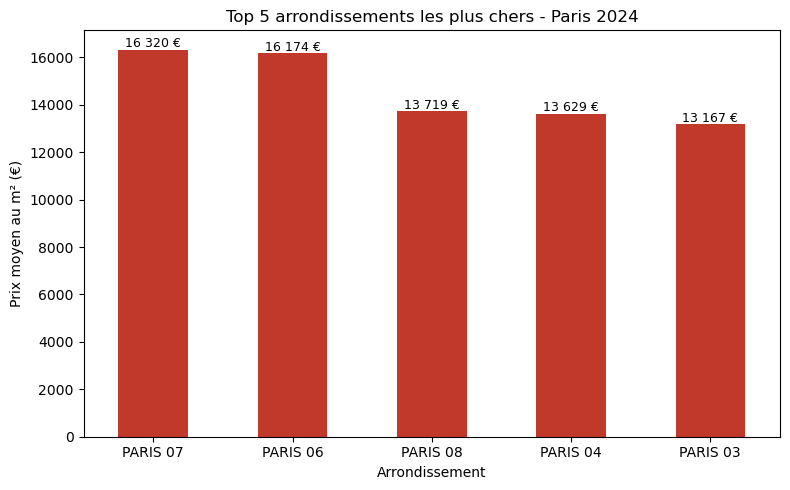

In [24]:

top5 = prix_par_commune.head(5)
fig, ax = plt.subplots(figsize=(8, 5))
bars = top5.plot(kind="bar", ax=ax, color="#c0392b")
for i, val in enumerate(top5):
    ax.text(i, val + 100, f"{int(val):,} €".replace(",", " "), 
            ha="center", fontsize=9)
ax.set_title("Top 5 arrondissements les plus chers - Paris 2024")
ax.set_xlabel("Arrondissement")
ax.set_ylabel("Prix moyen au m² (€)")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("top5_arrondissements.png", dpi=150)
plt.show()

In [27]:
colonnes_utiles = ["Date mutation", "Commune", "Type local", 
                   "Valeur fonciere", "Surface reelle bati", 
                   "Prix au m2", "Nombre pieces principales", "Mois"]
df_export = df75[colonnes_utiles].copy()
df_export.to_csv("immobilier_paris_2024.csv", index=False, sep=",", decimal=".")
print("Fais :", df_export.shape)

Fais : (28515, 8)


In [ ]:
colonnes_utiles = ["Date mutation", "Commune", "Type local", 
                   "Valeur fonciere", "Surface reelle bati", 
                   "Prix au m2", "Nombre pieces principales", "Mois"]
df_export = df75[colonnes_utiles].copy()
df_export["Prix au m2"] = df_export["Prix au m2"].round(2)
df_export["Valeur fonciere"] = df_export["Valeur fonciere"].round(2)
df_export["Surface reelle bati"] = df_export["Surface reelle bati"].round(2)
df_export.to_csv("immobilier_paris_2024.csv", index=False, sep=",", decimal=".")
print("Export terminé :", df_export.shape)

Export terminé : (28515, 8)
